In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "cs195-ska-projects/shared/ska_agent-1.0.0-8"))

from ska_agent.models.embedding import Embedder
from shared.constants import LAMBDA_GRID, MODES, MODE_COLORS, LAMBDA_BINS, EPS
from shared.corpus import make_officeqa_synthetic_corpus, build_segments_from_texts
from shared.sweep import generate_lambda_sweep_records
from shared.io_utils import save_records, save_held_out_qids

OUT = os.path.join(PROJECT_ROOT, "outputs", "week6")
os.makedirs(OUT, exist_ok=True)
print(f"OUT directory: {OUT}")

SEED = 0
np.random.seed(SEED)

OUT directory: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6


In [2]:
print("Building scaled corpus (7 paraphrases per triple)...")
segment_texts, questions, relevant_by_qid, triples_by_qid = make_officeqa_synthetic_corpus(
    n_per_mode=25, n_paraphrases=7, seed=SEED,
)
print(f"  {len(segment_texts)} segments, {len(questions)} questions")
print(f"  by mode: {Counter(q.question_type for q in questions)}")

Building scaled corpus (7 paraphrases per triple)...
  275 segments, 700 questions
  by mode: Counter({'LOOKUP': 175, 'MULTI_DOC': 175, 'COMPUTE': 175, 'MULTI_STEP': 175})


In [3]:
rng = np.random.default_rng(SEED)

# Group triples by mode without sorting (avoids mixed-type comparison error).
triples_by_mode = {mode: [] for mode in MODES}
seen = set()
for q in questions:
    triple = triples_by_qid[q.question_id]
    mode = q.question_type
    # Use (triple, mode) as a hashable key. Tuples containing tuples are hashable.
    key = (triple, mode)
    if key not in seen:
        seen.add(key)
        triples_by_mode[mode].append(triple)

total_unique = sum(len(v) for v in triples_by_mode.values())
print(f"{total_unique} unique triples across all modes")
for mode in MODES:
    print(f"  {mode}: {len(triples_by_mode[mode])} triples")

held_out_triples = set()
for mode in MODES:
    mode_triples = triples_by_mode[mode]
    rng.shuffle(mode_triples)
    n_test = max(1, int(0.2 * len(mode_triples)))
    held_out_triples.update(mode_triples[:n_test])

held_out_qids = {q.question_id for q in questions
                 if triples_by_qid[q.question_id] in held_out_triples}
train_qids = {q.question_id for q in questions if q.question_id not in held_out_qids}

print(f"\nTrain qids: {len(train_qids)} | Held-out qids: {len(held_out_qids)}")
save_held_out_qids(held_out_qids, f"{OUT}/held_out_qids.json")

100 unique triples across all modes
  LOOKUP: 25 triples
  MULTI_DOC: 25 triples
  COMPUTE: 25 triples
  MULTI_STEP: 25 triples

Train qids: 560 | Held-out qids: 140
Saved 140 held-out qids to: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6/held_out_qids.json


In [4]:
print("Loading embedder and embedding segments...")
embedder = Embedder(model_name="all-MiniLM-L6-v2")
segments = build_segments_from_texts(segment_texts, embedder)

train_questions = [q for q in questions if q.question_id in train_qids]
test_questions = [q for q in questions if q.question_id in held_out_qids]

print(f"Sweeping lambda on {len(train_questions)} training queries...")
train_records = generate_lambda_sweep_records(
    segments=segments, questions=train_questions,
    relevant_by_qid=relevant_by_qid, embed_fn=embedder.embed_single,
)
save_records(train_records, f"{OUT}/train_sweep_records.json")

Loading embedder and embedding segments...
No GPU found. Using lightweight CPU embedder: Alibaba-NLP/gte-Qwen2-1.5B-instruct
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/kevincapcha/PycharmProjects/CS195S2026/outputs/cs195-ska-projects/shared/ska_agent-1.0.0-8/ska_agent/models/embedding.py:51: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embedding_dim = self.model.get_sentence_embedding_dimension()


Embedder ready (dim=384)
Sweeping lambda on 560 training queries...
  processed 50/560 questions...
  processed 100/560 questions...
  processed 150/560 questions...
  processed 200/560 questions...
  processed 250/560 questions...
  processed 300/560 questions...
  processed 350/560 questions...
  processed 400/560 questions...
  processed 450/560 questions...
  processed 500/560 questions...
  processed 550/560 questions...
Saved 4480 records to: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6/train_sweep_records.json


In [5]:
print(f"Sweeping lambda on {len(test_questions)} held-out test queries...")
test_records = generate_lambda_sweep_records(
    segments=segments, questions=test_questions,
    relevant_by_qid=relevant_by_qid, embed_fn=embedder.embed_single,
)
save_records(test_records, f"{OUT}/test_sweep_records.json")

Sweeping lambda on 140 held-out test queries...
  processed 50/140 questions...
  processed 100/140 questions...
Saved 1120 records to: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6/test_sweep_records.json


In [6]:
optimal = [r for r in train_records if r["is_optimal"]]
print(f"\n{'Mode':<12} {'AvgCov':>8} {'AvgPrec':>9} {'AvgF1':>8} {'AvgSegs':>9}  Lambda Dist")
print("-" * 90)
for mode in MODES:
    m = [r for r in optimal if r["mode"] == mode]
    print(f"{mode:<12} {np.mean([r['evidence_coverage'] for r in m]):>8.3f} "
          f"{np.mean([r['retrieval_precision'] for r in m]):>9.3f} "
          f"{np.mean([r['retrieval_f1'] for r in m]):>8.3f} "
          f"{np.mean([r['num_segments'] for r in m]):>9.2f}  "
          f"{Counter(r['lambda'] for r in m)}")


Mode           AvgCov   AvgPrec    AvgF1   AvgSegs  Lambda Dist
------------------------------------------------------------------------------------------
LOOKUP          1.000     1.000    1.000      1.00  Counter({0.02: 69, 0.05: 41, 0.01: 26, 0.005: 3, 0.1: 1})
MULTI_DOC       0.479     0.860    0.592      1.22  Counter({0.05: 99, 0.1: 17, 0.5: 12, 0.001: 10, 0.02: 2})
COMPUTE         0.418     0.679    0.484      1.52  Counter({0.05: 73, 0.02: 23, 0.001: 19, 0.5: 19, 0.1: 5, 0.01: 1})
MULTI_STEP      0.410     0.851    0.502      1.86  Counter({0.05: 68, 0.02: 31, 0.001: 22, 0.1: 16, 0.5: 1, 0.2: 1, 0.01: 1})


In [7]:
from shared.scoring import ensure_1d

def build_training_dataset(records, embed_fn):
    from shared.scoring import ensure_1d
    optimal = [r for r in records if r["is_optimal"]]
    queries = [r["query"] for r in optimal]
    modes = [r["mode"] for r in optimal]
    y = np.asarray([r["lambda"] for r in optimal], dtype=np.float32)
    embeddings = [ensure_1d(embed_fn(q)) for q in queries]
    X = np.asarray(embeddings, dtype=np.float32)
    return X, y, queries, modes

def stratified_train_val_split(X, y, modes, val_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    modes_arr = np.asarray(modes)
    train_idx, val_idx = [], []
    for mode in sorted(set(modes)):
        mode_indices = np.where(modes_arr == mode)[0]
        rng.shuffle(mode_indices)
        n_val = max(1, int(len(mode_indices) * val_frac))
        val_idx.extend(mode_indices[:n_val])
        train_idx.extend(mode_indices[n_val:])
    train_idx = np.asarray(train_idx)
    val_idx = np.asarray(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx], train_idx, val_idx

class LambdaPredictor(nn.Module):
    """Small MLP that predicts log(lambda) from a query embedding."""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

X, y, optimal_queries, optimal_modes = build_training_dataset(
    train_records, embedder.embed_single
)
X_train, X_val, y_train, y_val, train_idx, val_idx = stratified_train_val_split(
    X, y, optimal_modes, val_frac=0.2, seed=SEED,
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
input_dim = X_train.shape[1]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(np.log(np.clip(y_train, EPS, None)), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_log_tensor = torch.tensor(np.log(np.clip(y_val, EPS, None)), dtype=torch.float32)

model = LambdaPredictor(input_dim=input_dim, hidden_dim=64)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 200

train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    pred_train_log = model(X_train_tensor)
    train_loss = criterion(pred_train_log, y_train_log_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(float(train_loss.item()))

    model.eval()
    with torch.no_grad():
        pred_val_log = model(X_val_tensor)
        val_loss = criterion(pred_val_log, y_val_log_tensor)
    val_losses.append(float(val_loss.item()))

    if epoch % 50 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:03d} | train log-MSE = {train_loss.item():.6f} | "
              f"val log-MSE = {val_loss.item():.6f}")

model.eval()
with torch.no_grad():
    train_mse = criterion(model(X_train_tensor), y_train_log_tensor).item()
    val_mse = criterion(model(X_val_tensor), y_val_log_tensor).item()

print(f"\nTraining MSE on log(lambda): {train_mse}")
print(f"Validation MSE on log(lambda): {val_mse}")

X_train: (448, 384), y_train: (448,)
X_val:   (112, 384),   y_val:   (112,)
Epoch 000 | train log-MSE = 13.442678 | val log-MSE = 14.743163
Epoch 050 | train log-MSE = 1.878813 | val log-MSE = 2.656986
Epoch 100 | train log-MSE = 1.644234 | val log-MSE = 2.495830
Epoch 150 | train log-MSE = 1.558102 | val log-MSE = 2.475758
Epoch 199 | train log-MSE = 1.475881 | val log-MSE = 2.457319

Training MSE on log(lambda): 1.4740235805511475
Validation MSE on log(lambda): 2.457319498062134


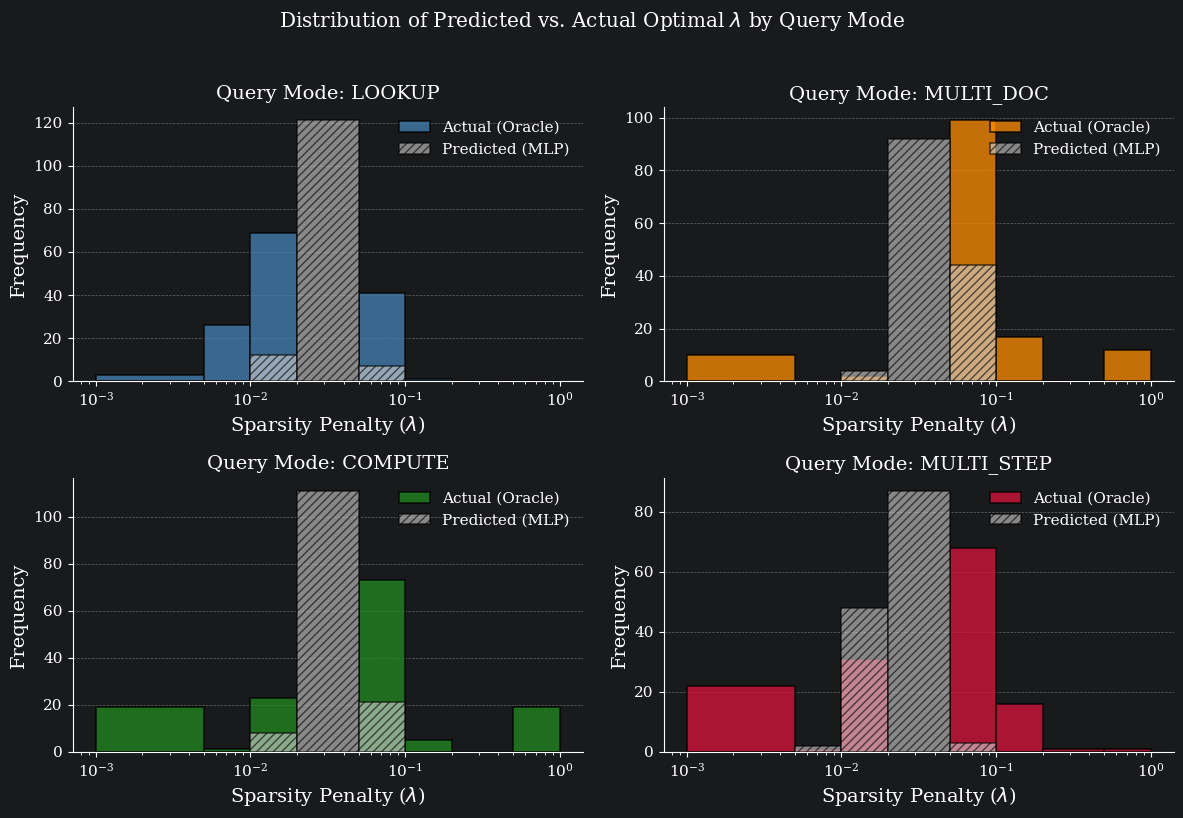

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Set Publication-Quality Global Parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',          # Matches LaTeX standard fonts (e.g., Computer Modern/Times)
    'axes.labelsize': 14,            # Larger, readable axis labels
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.spines.top': False,        # Remove chart junk (Tufte principles)
    'axes.spines.right': False,
    'axes.axisbelow': True,          # Put gridlines behind the data
    'legend.fontsize': 11,
    'legend.frameon': False          # Clean, borderless legends
})

with torch.no_grad():
    X_all_tensor = torch.tensor(X, dtype=torch.float32)
    all_preds = torch.exp(model(X_all_tensor)).numpy()

optimal_modes_arr = np.asarray(optimal_modes)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, mode in zip(axes.flatten(), MODES):
    mask = optimal_modes_arr == mode

    # 2. Plot Actual (Oracle) - Solid color with sharp borders
    ax.hist(y[mask], bins=LAMBDA_BINS, alpha=0.75,
            label="Actual (Oracle)", color=MODE_COLORS[mode],
            edgecolor='black', linewidth=1.2)

    # 3. Plot Predicted (MLP) - Neutral color with hatching for colorblind accessibility
    ax.hist(all_preds[mask], bins=LAMBDA_BINS, alpha=0.6,
            label="Predicted (MLP)", color="#D3D3D3",
            edgecolor='black', linewidth=1.2, hatch='////')

    ax.set_xscale("log")

    # 4. Use LaTeX math text for Lambda
    ax.set_title(f"Query Mode: {mode}")
    ax.set_xlabel("Sparsity Penalty ($\\lambda$)")
    ax.set_ylabel("Frequency")

    # Subtle horizontal grid for easier visual value tracing
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    ax.legend(loc='upper right')

# Note: In actual NeurIPS papers, suptitles are usually omitted in favor of LaTeX figure captions.
# But we will include a cleaned-up version here.
plt.suptitle("Distribution of Predicted vs. Actual Optimal $\\lambda$ by Query Mode", y=1.02)

plt.tight_layout()

# 5. Save as PDF for LaTeX compatibility, and high-DPI PNG for quick viewing/slides
plt.savefig(f"{OUT}/predicted_vs_actual_lambda_hist_neurips.pdf", format='pdf', bbox_inches='tight')
plt.savefig(f"{OUT}/predicted_vs_actual_lambda_hist_neurips.png", format='png', bbox_inches='tight', dpi=300)

plt.show()

In [9]:
import os
checkpoint_path = f"{OUT}/lambda_predictor_week6_checkpoint.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "hidden_dim": 64,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "lambda_grid": LAMBDA_GRID,
    },
    checkpoint_path,
)
print(f"Saved checkpoint to: {checkpoint_path}")

Saved checkpoint to: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6/lambda_predictor_week6_checkpoint.pt


In [10]:
results_by_seed = {}
for trial_seed in [0, 1, 2]:
    torch.manual_seed(trial_seed)
    np.random.seed(trial_seed)
    rng = np.random.default_rng(trial_seed)

    X_tr, X_va, y_tr, y_va, _, _ = stratified_train_val_split(
        X, y, optimal_modes, val_frac=0.2, seed=trial_seed,
    )
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(np.log(np.clip(y_tr, EPS, None)), dtype=torch.float32)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(np.log(np.clip(y_va, EPS, None)), dtype=torch.float32)

    m = LambdaPredictor(input_dim=input_dim, hidden_dim=64)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(200):
        m.train(); opt.zero_grad()
        loss = crit(m(X_tr_t), y_tr_t)
        loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        results_by_seed[trial_seed] = {
            "train_mse": float(crit(m(X_tr_t), y_tr_t).item()),
            "val_mse": float(crit(m(X_va_t), y_va_t).item()),
        }

import statistics
val_mses = [r["val_mse"] for r in results_by_seed.values()]
print(f"Val MSE across seeds: {val_mses}")
print(f"Mean = {statistics.mean(val_mses):.3f}, "
      f"Std = {statistics.stdev(val_mses):.3f}")

Val MSE across seeds: [2.4017348289489746, 2.726889133453369, 1.6051883697509766]
Mean = 2.245, Std = 0.577


In [11]:
import os
import subprocess

print("Notebook CWD:", os.getcwd())
print("Resolved OUT:", os.path.abspath(OUT))
print("OUT realpath:", os.path.realpath(OUT))
print()
print("Files via os.listdir:")
print(os.listdir(os.path.abspath(OUT)))
print()
print("Files via shell ls (run from notebook):")
result = subprocess.run(["ls", "-la", os.path.abspath(OUT)], capture_output=True, text=True)
print(result.stdout)

Notebook CWD: /Users/kevincapcha/PycharmProjects/CS195S2026/notebooks
Resolved OUT: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6
OUT realpath: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6

Files via os.listdir:
['test_sweep_records.json', 'predicted_vs_actual_lambda_hist.png', 'train_sweep_records.json', 'lambda_predictor_week6_checkpoint.pt', 'held_out_qids.json']

Files via shell ls (run from notebook):
total 18848
drwxr-xr-x@  7 kevincapcha  staff      224 Apr 27 00:42 .
drwxr-xr-x@ 18 kevincapcha  staff      576 May  7 22:40 ..
-rw-r--r--@  1 kevincapcha  staff     2669 May  7 22:40 held_out_qids.json
-rw-r--r--@  1 kevincapcha  staff   119117 May  7 22:41 lambda_predictor_week6_checkpoint.pt
-rw-r--r--@  1 kevincapcha  staff    66452 May  7 22:41 predicted_vs_actual_lambda_hist.png
-rw-r--r--@  1 kevincapcha  staff  1636569 May  7 22:41 test_sweep_records.json
-rw-r--r--@  1 kevincapcha  staff  6523026 May  7 22:41 train_sweep_records.json

